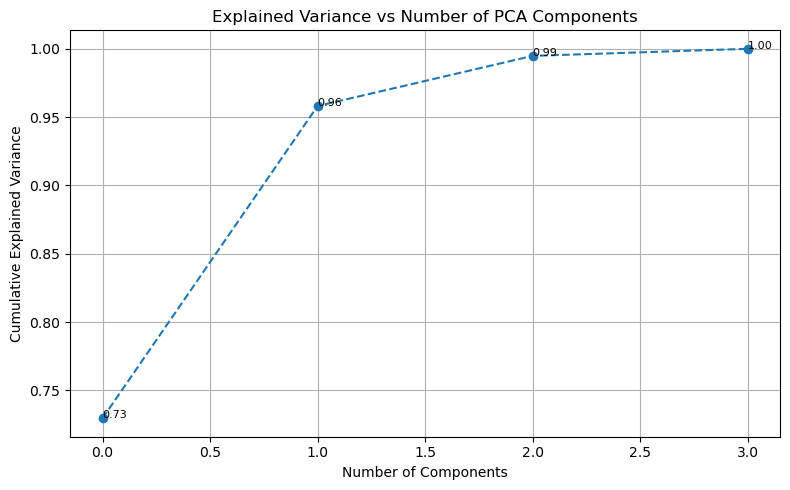

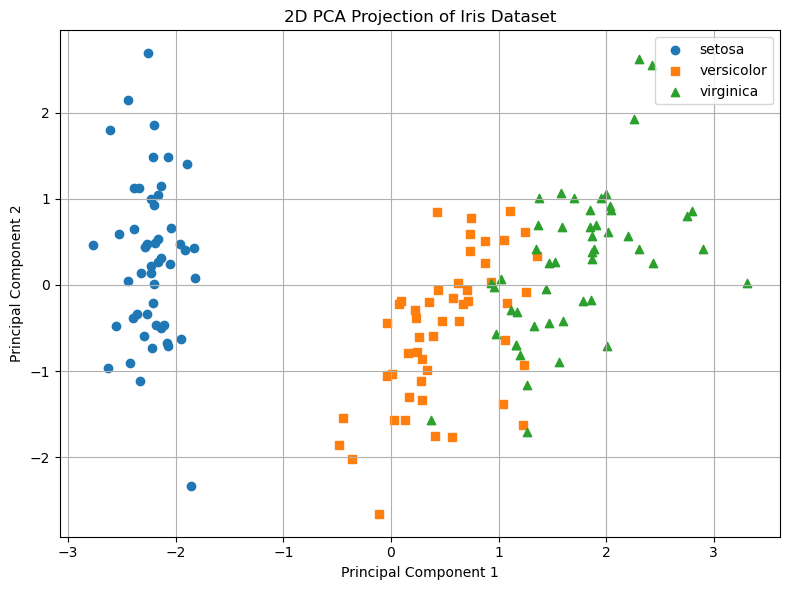

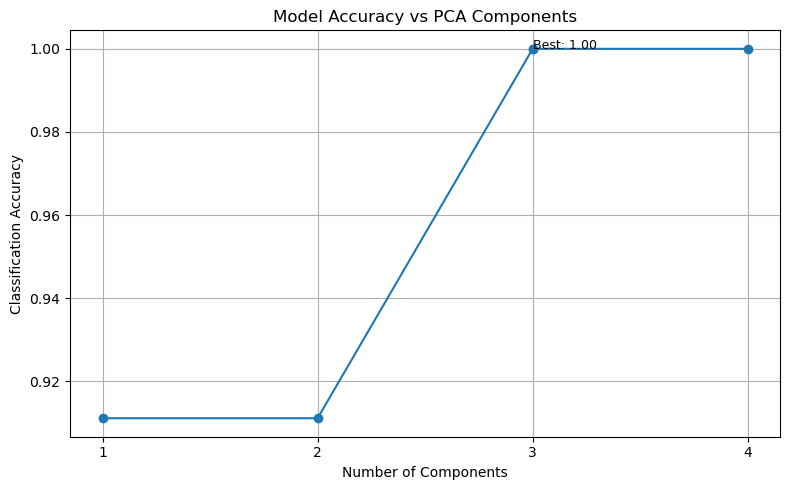

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# -------------------------------
# Load and prepare data
# -------------------------------
data = load_iris()
X = data.data
y = data.target
target_names = data.target_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# PCA - full for variance plot
# -------------------------------
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# -------------------------------
# 📈 Plot 1: Explained Variance
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(cumulative_var, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of PCA Components')
plt.grid(True)

# Annotation (important for teaching)
for i, val in enumerate(cumulative_var):
    plt.text(i, val, f"{val:.2f}", fontsize=8)

plt.tight_layout()
plt.show()

# -------------------------------
# 🌈 Plot 2: 2D PCA Scatter
# -------------------------------
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

markers = ['o', 's', '^']  # accessible markers
for i, target in enumerate(np.unique(y)):
    plt.scatter(
        X_pca_2[y == target, 0],
        X_pca_2[y == target, 1],
        label=target_names[target],
        marker=markers[i]
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Projection of Iris Dataset')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------
# 📉 Plot 3: Accuracy vs Components
# -------------------------------
accuracies = []

for n in range(1, 5):
    pca_n = PCA(n_components=n)
    X_pca_n = pca_n.fit_transform(X_scaled)

    X_train, X_test, y_train, y_test = train_test_split(
        X_pca_n, y, test_size=0.3, random_state=42
    )

    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    accuracies.append(acc)

plt.figure(figsize=(8,5))
plt.plot(range(1, 5), accuracies, marker='o', linestyle='-')

plt.xlabel('Number of Components')
plt.ylabel('Classification Accuracy')
plt.title('Model Accuracy vs PCA Components')
plt.xticks(range(1,5))
plt.grid(True)

# Highlight best point
best_idx = np.argmax(accuracies)
plt.scatter(best_idx+1, accuracies[best_idx])
plt.text(best_idx+1, accuracies[best_idx],
         f"Best: {accuracies[best_idx]:.2f}",
         fontsize=9)

plt.tight_layout()
plt.show()